In [32]:
# Install necessary libraries
# !pip install gymnasium[box2d] stable-baselines3 shimmy imageio numpy matplotlib pandas

import os
import imageio
import numpy as np
import torch as nn
import pandas as pd
import gymnasium as gym
from typing import Callable
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.results_plotter import load_results, ts2xy
from stable_baselines3.common.vec_env import VecNormalize, DummyVecEnv, VecMonitor

# Create directories for logging and models
LOG_DIR = "./logs/"
os.makedirs(LOG_DIR, exist_ok=True)

In [ ]:
def record_improved_gif(model_path, stats_path, output_filename="improved_walker.gif"):
    # 1. Recreate the environment exactly as it was during training
    # Note: render_mode must be 'rgb_array' for imageio to capture frames
    env = gym.make("BipedalWalker-v3", render_mode="rgb_array")
    env = DummyVecEnv([lambda: env])
    
    # 2. Load the normalization statistics (CRITICAL for improved models)
    env = VecNormalize.load(stats_path, env)
    
    # IMPORTANT: Turn off training and reward normalization for testing/rendering
    env.training = False 
    env.norm_reward = False 
    
    # 3. Load the trained model
    model = PPO.load(model_path, env=env)
    
    frames = []
    obs = env.reset()
    
    print("Recording frames...")
    # Record for one full episode (usually 1600 steps max for BipedalWalker)
    for i in range(1600):
        action, _ = model.predict(obs, deterministic=True)
        obs, rewards, dones, info = env.step(action)
        
        # Grab the frame from the vectorized environment
        # BipedalWalker-v3 returns a list of images (one per sub-env)
        frame = env.env_method("render")[0]
        frames.append(frame)
        
        if dones[0]:
            print(f"Episode finished in {i} steps.")
            break
            
    # 4. Save as GIF
    print(f"Saving GIF to {output_filename}...")
    imageio.mimsave(output_filename, frames, fps=30)
    print("Done!")

def save_gif(model, env, filename="agent_run.gif", length=500):
    """
    Runs the agent in the environment and saves the render as a GIF.
    """
    images = []
    vec_env = model.get_env()
    obs = vec_env.reset()
    
    print(f"Recording GIF: {filename}...")
    for i in range(length):
        action, _ = model.predict(obs, deterministic=True)
        obs, rewards, dones, info = vec_env.step(action)
        
        # Capture the frame
        # Note: BipedalWalker returns an RGB array when render_mode='rgb_array'
        img = vec_env.env_method("render")[0] 
        images.append(img)
        
        if dones[0]:
            break

    imageio.mimsave(filename, images, fps=30)
    print(f"Saved {filename}")

def moving_average(values, window):
    """
    Smooths the data for cleaner plotting.
    """
    weights = np.repeat(1.0, window) / window
    return np.convolve(values, weights, 'valid')

def plot_results(log_folder, title="Learning Curve"):
    x, y = ts2xy(load_results(log_folder), 'timesteps')
    y = moving_average(y, window=50)
    x = x[len(x) - len(y):]
    return x, y

def get_data_from_monitor(log_dir, name_filter):
    data = []
    for file in os.listdir(log_dir):
        if file.endswith(".csv") and name_filter in file:
            df = pd.read_csv(os.path.join(log_dir, file), skiprows=1)
            data.append(df)
    if not data: return None
    df_concat = pd.concat(data)
    # Sort by time
    df_concat = df_concat.sort_values(by='t')
    
    # Calculate cumulative timesteps
    df_concat['cumsum_l'] = df_concat['l'].cumsum()
    
    # Smooth rewards
    rewards = df_concat['r'].rolling(window=50).mean()
    return df_concat['cumsum_l'], rewards

# Test environment setup
env_test = gym.make("BipedalWalker-v3", render_mode="rgb_array")
print("Environment Observation Space:", env_test.observation_space)
print("Environment Action Space:", env_test.action_space)
env_test.close()

Environment Observation Space: Box([-3.1415927 -5.        -5.        -5.        -3.1415927 -5.
 -3.1415927 -5.        -0.        -3.1415927 -5.        -3.1415927
 -5.        -0.        -1.        -1.        -1.        -1.
 -1.        -1.        -1.        -1.        -1.        -1.       ], [3.1415927 5.        5.        5.        3.1415927 5.        3.1415927
 5.        5.        3.1415927 5.        3.1415927 5.        5.
 1.        1.        1.        1.        1.        1.        1.
 1.        1.        1.       ], (24,), float32)
Environment Action Space: Box(-1.0, 1.0, (4,), float32)


In [8]:
# 1. Setup the Baseline Environment (No Normalization, Default Rewards)
baseline_env = gym.make("BipedalWalker-v3", render_mode="rgb_array")
baseline_env = Monitor(baseline_env, LOG_DIR + "baseline") # Wrap for logging
baseline_env = DummyVecEnv([lambda: baseline_env]) # Vectorize for SB3

# 2. Define the Baseline Model
baseline_model = PPO(
    "MlpPolicy", 
    baseline_env, 
    verbose=0,
    seed=42
)

# 3. Train Baseline (Keep low for testing code, increase to 300k+ for real results)
# SUGGESTED FOR ASSIGNMENT: 100_000 for quick checks, 500_000+ to solve
BASELINE_STEPS = 1_000_000 
print("Training Baseline Model...")
baseline_model.learn(total_timesteps=BASELINE_STEPS)
baseline_model.save(LOG_DIR + "baseline_model")
print("Baseline Training Complete.")

# 4. Save Baseline GIF
save_gif(baseline_model, baseline_env, filename="baseline_agent.gif")

Training Baseline Model...
Baseline Training Complete.
Recording GIF: baseline_agent.gif...


d:\Users\draar\AppData\Local\Programs\Python\Python311\Lib\site-packages\imageio\plugins\pillow.py:409: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


Saved baseline_agent.gif


In [9]:
# 1. Setup Improved Environment with Normalization
# VecNormalize is crucial for BipedalWalker
env_improved = gym.make("BipedalWalker-v3", render_mode="rgb_array")
env_improved = Monitor(env_improved, LOG_DIR + "improved")
env_improved = DummyVecEnv([lambda: env_improved])
env_improved = VecNormalize(env_improved, norm_obs=True, norm_reward=True, clip_obs=10.)

# 2. Define Improved Model with Tuned Hyperparameters
# These params are derived from standard RL benchmarks for BipedalWalker
improved_model = PPO(
    "MlpPolicy",
    env_improved,
    learning_rate=0.0003,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.001, # Slight exploration encouragement
    verbose=0,
    seed=42,
    policy_kwargs=dict(net_arch=[dict(pi=[256, 256], vf=[256, 256])]) # Deeper network
)

# 3. Train Improved Model
IMPROVED_STEPS = 1_000_000 # Increase this to 500k-1M for final submission
print("Training Improved Model...")
improved_model.learn(total_timesteps=IMPROVED_STEPS)

# Important: Save the model AND the normalization statistics
improved_model.save(LOG_DIR + "improved_model")
env_improved.save(LOG_DIR + "vec_normalize.pkl")
print("Improved Training Complete.")

Training Improved Model...


d:\Users\draar\AppData\Local\Programs\Python\Python311\Lib\site-packages\stable_baselines3\common\policies.py:486: UserWarning: As shared layers in the mlp_extractor are removed since SB3 v1.8.0, you should now pass directly a dictionary and not a list (net_arch=dict(pi=..., vf=...) instead of net_arch=[dict(pi=..., vf=...)])
  warnings.warn(


Improved Training Complete.


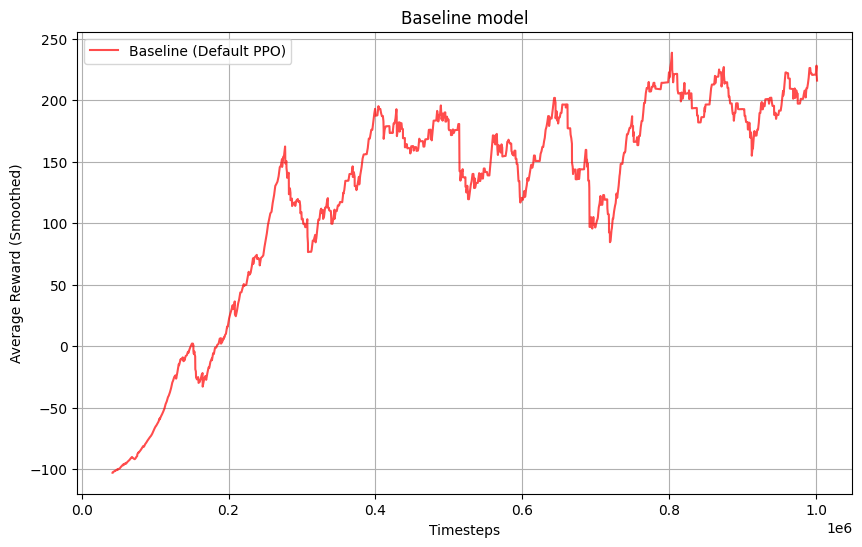

In [ ]:
plt.figure(figsize=(10, 6))

# Plot Baseline
bx, by = get_data_from_monitor(LOG_DIR, "baseline")
plt.plot(bx, by, label="Baseline (Default PPO)", color='red', alpha=0.7)

plt.xlabel("Timesteps")
plt.ylabel("Average Reward (Smoothed)")
plt.title("Baseline model")
plt.legend()
plt.grid(True)
plt.savefig("Basline_agent.png")
plt.show()

In [ ]:
# Execute the recording
record_improved_gif(
    model_path=LOG_DIR + "improved_model.zip", 
    stats_path=LOG_DIR + "vec_normalize.pkl",
    output_filename="final_submission_walker.gif"
)

Recording frames...
Episode finished in 1599 steps.
Saving GIF to final_submission_walker.gif...


d:\Users\draar\AppData\Local\Programs\Python\Python311\Lib\site-packages\imageio\plugins\pillow.py:409: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


Done!


In [ ]:
env_dynamic = gym.make("BipedalWalker-v3", render_mode="rgb_array")
env_dynamic = Monitor(env_dynamic, LOG_DIR + "dynamic")
env_dynamic = DummyVecEnv([lambda: env_dynamic])
env_dynamic = VecNormalize(env_dynamic, norm_obs=True, norm_reward=True, clip_obs=10.)

DYNAMIC_STEPS = 1_000_000

class TimestepCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)

    def _on_step(self) -> bool:
        if self.num_timesteps % 10000 == 0:
            print(f"Timestep: {self.num_timesteps}")
        return True 
    
def linear_schedule(initial_value: float) -> Callable[[float], float]:
    """
    Linear learning rate schedule.
    :param initial_value: Initial learning rate.
    :return: schedule function.
    """
    def func(progress_remaining: float) -> float:
        # progress_remaining starts at 1.0 and decreases to 0.0
        return progress_remaining * initial_value
    return func

# print("working")

dynamic_model = PPO(
    "MlpPolicy",
    env_dynamic,
    learning_rate=linear_schedule(0.0003),
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.001, # variable encouragement
    verbose=0,
    seed=42,
    policy_kwargs=dict(net_arch=[dict(pi=[256, 256], vf=[256, 256])])
)

callback = TimestepCallback()
print("Training Dynamic Model...")
dynamic_model.learn(total_timesteps=DYNAMIC_STEPS, callback=callback)

dynamic_model.save(LOG_DIR + "dynamic_model")
env_dynamic.save(LOG_DIR + "vec_normalize_dynamic.pkl")
print("Dynamic Model Training Complete.")

d:\Users\draar\AppData\Local\Programs\Python\Python311\Lib\site-packages\stable_baselines3\common\policies.py:486: UserWarning: As shared layers in the mlp_extractor are removed since SB3 v1.8.0, you should now pass directly a dictionary and not a list (net_arch=dict(pi=..., vf=...) instead of net_arch=[dict(pi=..., vf=...)])
  warnings.warn(


Training Dynamic Model...
Timestep: 10000
Timestep: 20000
Timestep: 30000
Timestep: 40000
Timestep: 50000
Timestep: 60000
Timestep: 70000
Timestep: 80000
Timestep: 90000
Timestep: 100000
Timestep: 110000
Timestep: 120000
Timestep: 130000
Timestep: 140000
Timestep: 150000
Timestep: 160000
Timestep: 170000
Timestep: 180000
Timestep: 190000
Timestep: 200000
Timestep: 210000
Timestep: 220000
Timestep: 230000
Timestep: 240000
Timestep: 250000
Timestep: 260000
Timestep: 270000
Timestep: 280000
Timestep: 290000
Timestep: 300000
Timestep: 310000
Timestep: 320000
Timestep: 330000
Timestep: 340000
Timestep: 350000
Timestep: 360000
Timestep: 370000
Timestep: 380000
Timestep: 390000
Timestep: 400000
Timestep: 410000
Timestep: 420000
Timestep: 430000
Timestep: 440000
Timestep: 450000
Timestep: 460000
Timestep: 470000
Timestep: 480000
Timestep: 490000
Timestep: 500000
Timestep: 510000
Timestep: 520000
Timestep: 530000
Timestep: 540000
Timestep: 550000
Timestep: 560000
Timestep: 570000
Timestep: 5800

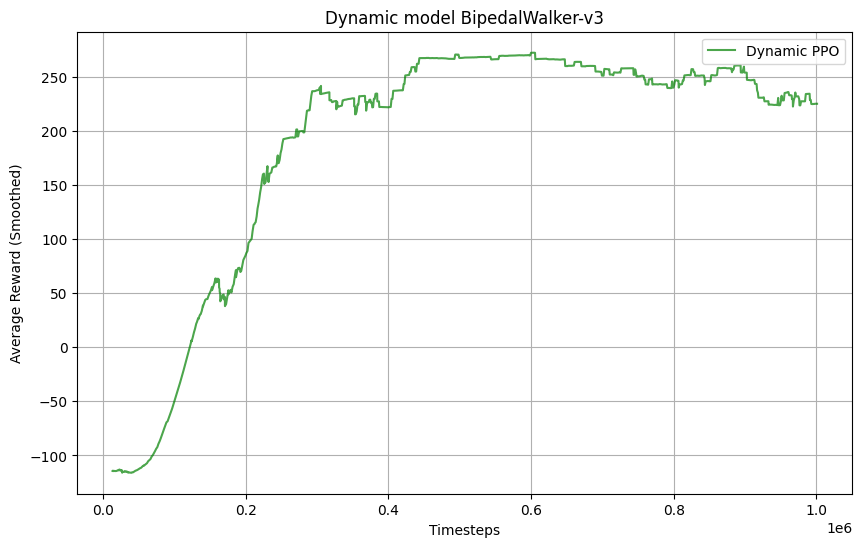

In [46]:
dx, dy = get_data_from_monitor(LOG_DIR, "dynamic")
if dx is None or ix is None:
    raise ValueError("Monitor CSV files not found. Check your Monitor paths and naming!")

plt.figure(figsize=(10,6))
plt.plot(dx, dy, label="Dynamic PPO", color='green', alpha=0.7)
plt.xlabel("Timesteps")
plt.ylabel("Average Reward (Smoothed)")
plt.title("Dynamic model BipedalWalker-v3")
plt.legend()
plt.grid(True)
plt.savefig("dynamic_100k.png")
plt.show()

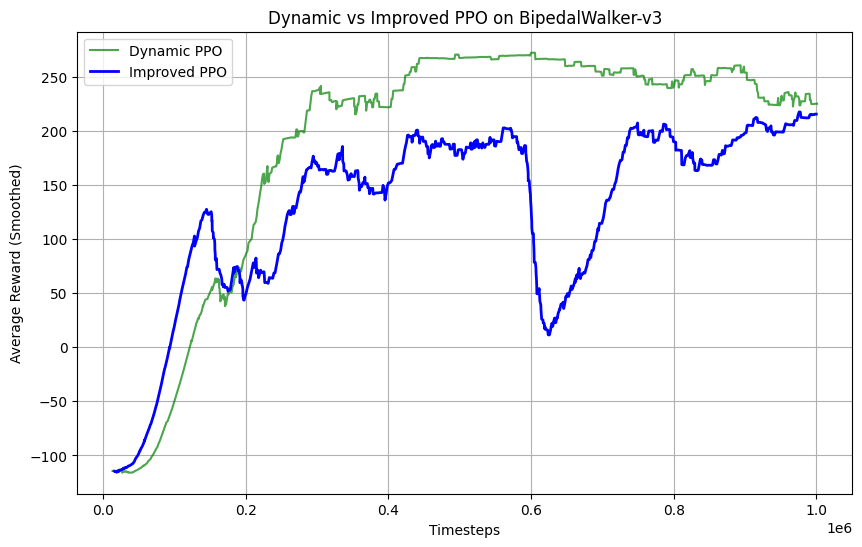

In [ ]:
dx, dy = get_data_from_monitor(LOG_DIR, "dynamic")
if dx is None or ix is None:
    raise ValueError("Monitor CSV files not found. Check your Monitor paths and naming!")

plt.figure(figsize=(10,6))
plt.plot(dx, dy, label="Dynamic PPO", color='green', alpha=0.7)
plt.plot(ix, iy, label="Improved PPO", color='blue', linewidth=2)
plt.xlabel("Timesteps")
plt.ylabel("Average Reward (Smoothed)")
plt.title("Dynamic vs Improved PPO on BipedalWalker-v3")
plt.legend()
plt.grid(True)
plt.savefig("dynamic_vs_improved.png")
plt.show()

In [5]:
# Execute the recording
record_improved_gif(
    model_path=LOG_DIR + "dynamic_model.zip", 
    stats_path=LOG_DIR + "vec_normalize.pkl",
    output_filename="dynamic_model.gif"
)

Recording frames...
Episode finished in 1407 steps.
Saving GIF to dynamic_model.gif...


d:\Users\draar\AppData\Local\Programs\Python\Python311\Lib\site-packages\imageio\plugins\pillow.py:409: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


Done!


In [ ]:
import gymnasium as gym
import torch.nn as nn
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize
from stable_baselines3.common.callbacks import EvalCallback
from typing import Callable

# 1. CONSTANTS
LOG_DIR = "./logs/"
DYNAMIC_STEPS = 2_000_000  # BipedalWalker often needs >1M to perfect gait
N_ENVS = 8                # Number of parallel environments

# 2. LEARNING RATE SCHEDULE
def linear_schedule(initial_value: float) -> Callable[[float], float]:
    def func(progress_remaining: float) -> float:
        return progress_remaining * initial_value
    return func

# 3. ENVIRONMENT SETUP (Vectorized)
# make_vec_env handles the creation of multiple processes automatically
env_dynamic = make_vec_env("BipedalWalker-v3", n_envs=N_ENVS)

# Normalize observations and rewards (Crucial for PPO/BipedalWalker)
env_dynamic = VecNormalize(
    env_dynamic, 
    norm_obs=True, 
    norm_reward=True, 
    clip_obs=10.,
    gamma=0.99
)

# 4. CALLBACKS
# Separate evaluation env to test true performance without exploration noise/normalization updates
eval_env = make_vec_env("BipedalWalker-v3", n_envs=1)
eval_env = VecNormalize(eval_env, norm_obs=True, norm_reward=False, clip_obs=10., training=False)

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=LOG_DIR + "best_model",
    log_path=LOG_DIR + "results",
    eval_freq=max(10000 // N_ENVS, 1), # Adjust frequency for parallel envs
    deterministic=True,
    render=False
)

# 5. MODEL CONFIGURATION
dynamic_model = PPO(
    "MlpPolicy",
    env_dynamic,
    learning_rate=linear_schedule(3e-4),
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.001,
    use_sde=True,
    sde_sample_freq=4,
    verbose=1,
    seed=42,
    policy_kwargs=dict(
        log_std_init=-2,
        ortho_init=True,
        activation_fn=nn.Tanh,
        net_arch=dict(pi=[256, 256], vf=[256, 256])
    )
)

print("Training Dynamic Model with gSDE and Parallel Envs...")
# Note: total_timesteps is distributed across all envs
dynamic_model.learn(total_timesteps=DYNAMIC_STEPS, callback=eval_callback)

# Save final model and the normalization stats
dynamic_model.save(LOG_DIR + "final_dynamic_model")
env_dynamic.save(LOG_DIR + "vec_normalize_dynamic.pkl")
print("Training Complete.")

Using cpu device
Training Dynamic Model with gSDE and Parallel Envs...
Eval num_timesteps=10000, episode_reward=-91.69 +/- 0.15
Episode length: 112.40 +/- 1.50
---------------------------------
| eval/              |          |
|    mean_ep_length  | 112      |
|    mean_reward     | -91.7    |
| time/              |          |
|    total_timesteps | 10000    |
---------------------------------
New best mean reward!
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 178      |
|    ep_rew_mean     | -117     |
| time/              |          |
|    fps             | 3264     |
|    iterations      | 1        |
|    time_elapsed    | 5        |
|    total_timesteps | 16384    |
---------------------------------
Eval num_timesteps=20000, episode_reward=-94.54 +/- 0.44
Episode length: 114.40 +/- 3.07
----------------------------------------
| eval/                   |            |
|    mean_ep_length       | 114        |
|    mean_reward          | 

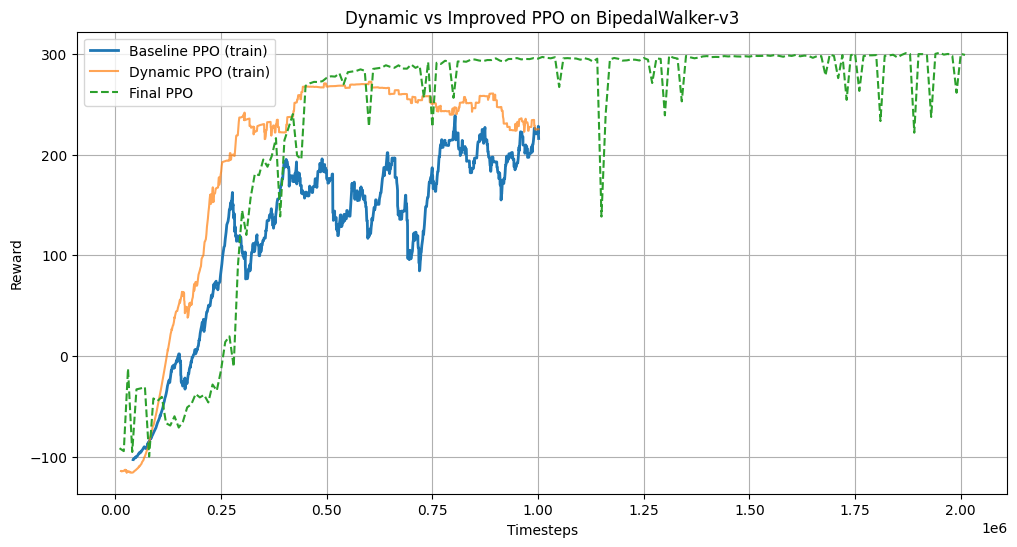

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Load monitor curves ----------
ix, iy = get_data_from_monitor(LOG_DIR, "baseline")
dx, dy = get_data_from_monitor(LOG_DIR, "dynamic")

if dx is None or ix is None:
    raise ValueError("Monitor CSV files not found. Check your Monitor paths and naming!")

# ---------- Load evaluation curve ----------
eval_data = np.load(LOG_DIR + "results/evaluations.npz")
eval_timesteps = eval_data["timesteps"]
eval_results = eval_data["results"]

eval_mean = np.mean(eval_results, axis=1)
eval_std = np.std(eval_results, axis=1)

# ---------- Plot everything ----------
plt.figure(figsize=(12, 6))

# Monitor curves
plt.plot(ix, iy, label="Baseline PPO (train)", linewidth=2)
plt.plot(dx, dy, label="Dynamic PPO (train)", alpha=0.7)

# Evaluation curve
plt.plot(eval_timesteps, eval_mean, label="Final PPO", linestyle="--")
# plt.fill_between(
#     eval_timesteps,
#     eval_mean - eval_std,
#     eval_mean + eval_std,
#     alpha=0.2,
#     label="Evaluation ± Std"
# )

plt.xlabel("Timesteps")
plt.ylabel("Reward")
plt.title("Dynamic vs Improved PPO on BipedalWalker-v3")
plt.legend()
plt.grid(True)

plt.savefig("all_curves_combined.png")
plt.show()


In [30]:
# Execute the recording
record_improved_gif(
    model_path=LOG_DIR + "best_model/best_model.zip", 
    stats_path=LOG_DIR + "vec_normalize_dynamic.pkl",
    output_filename="final_model_2.gif"
)

Recording frames...
Episode finished in 997 steps.
Saving GIF to final_model_2.gif...
Done!
